In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### Radial Envelope Geometry

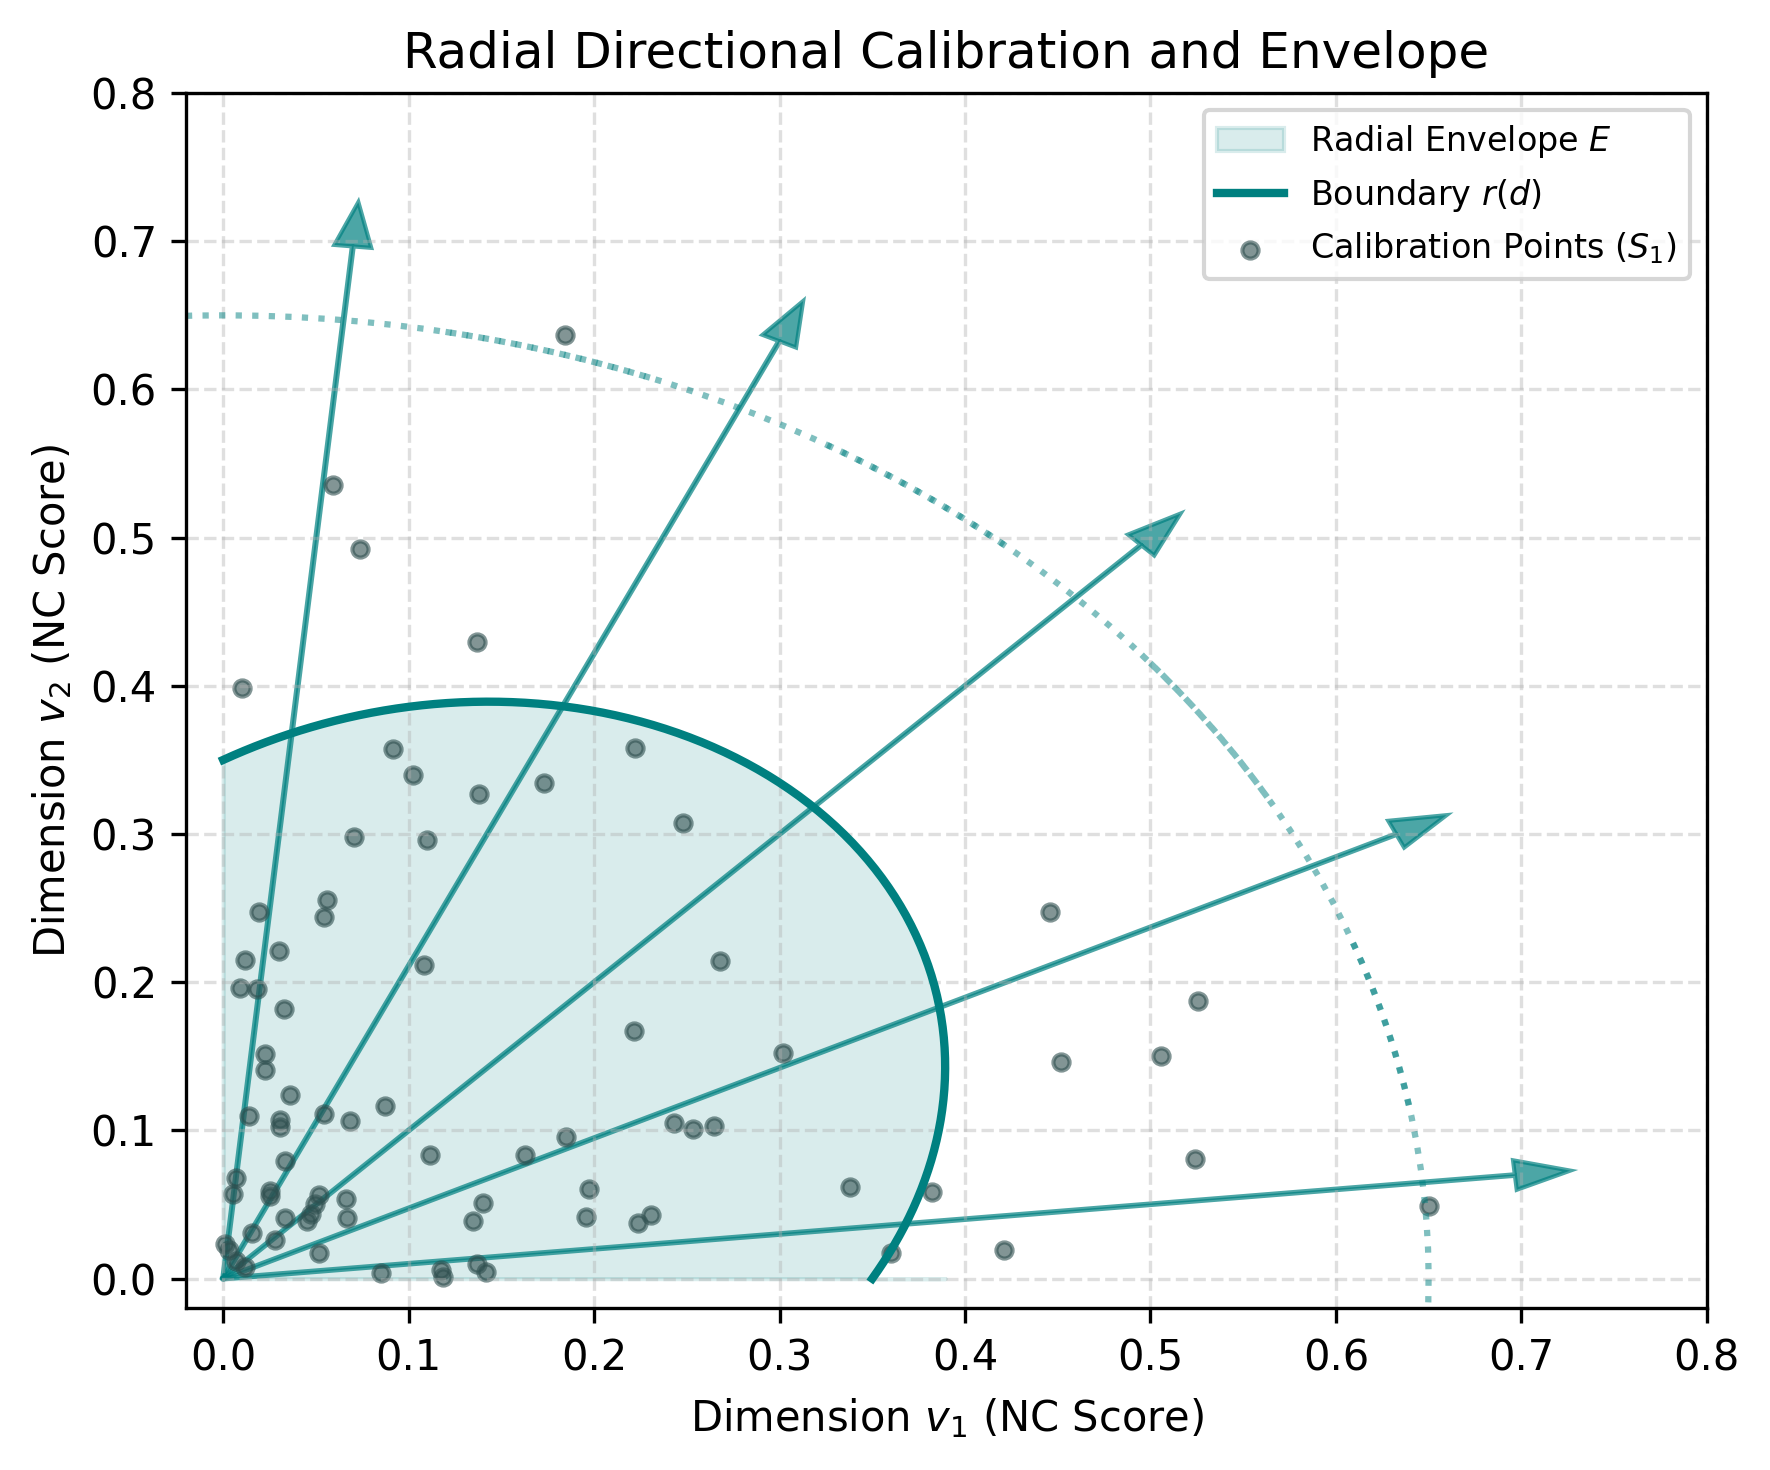

In [5]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
np.random.seed(42)

# Generate mock 2D nonconformity points
S1_x = np.random.exponential(scale=0.15, size=80)
S1_y = np.random.exponential(scale=0.15, size=80)

# Sample directions
thetas = np.linspace(0.1, np.pi/2 - 0.1, 5)
for th in thetas:
    u = np.array([np.cos(th), np.sin(th)])
    ax.arrow(0, 0, u[0]*0.7, u[1]*0.7, head_width=0.02, head_length=0.03, fc='teal', ec='teal', alpha=0.7)
    # Sector arc cone
    cone_th = np.linspace(th - np.deg2rad(15), th + np.deg2rad(15), 20)
    ax.plot(0.65*np.cos(cone_th), 0.65*np.sin(cone_th), color='teal', linestyle=':', alpha=0.5)

# Smooth calibrated radius curve
phi = np.linspace(0, np.pi/2, 100)
r_phi = 0.35 + 0.1 * np.sin(2 * phi)
ax.fill_between(r_phi * np.cos(phi), 0, r_phi * np.sin(phi), color='teal', alpha=0.15, label='Radial Envelope $E$')
ax.plot(r_phi * np.cos(phi), r_phi * np.sin(phi), color='teal', lw=2, label=r'Boundary $r(d)$')
ax.scatter(S1_x, S1_y, color='darkslategray', s=15, alpha=0.6, label='Calibration Points ($S_1$)')

ax.set_xlim(-0.02, 0.8)
ax.set_ylim(-0.02, 0.8)
ax.set_xlabel(r'Dimension $v_1$ (NC Score)')
ax.set_ylabel(r'Dimension $v_2$ (NC Score)')
ax.set_title('Radial Directional Calibration and Envelope')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
# plt.savefig('radial_envelope_concept.pdf')
# plt.close()

#### Strip envelope geometry and missing dimension

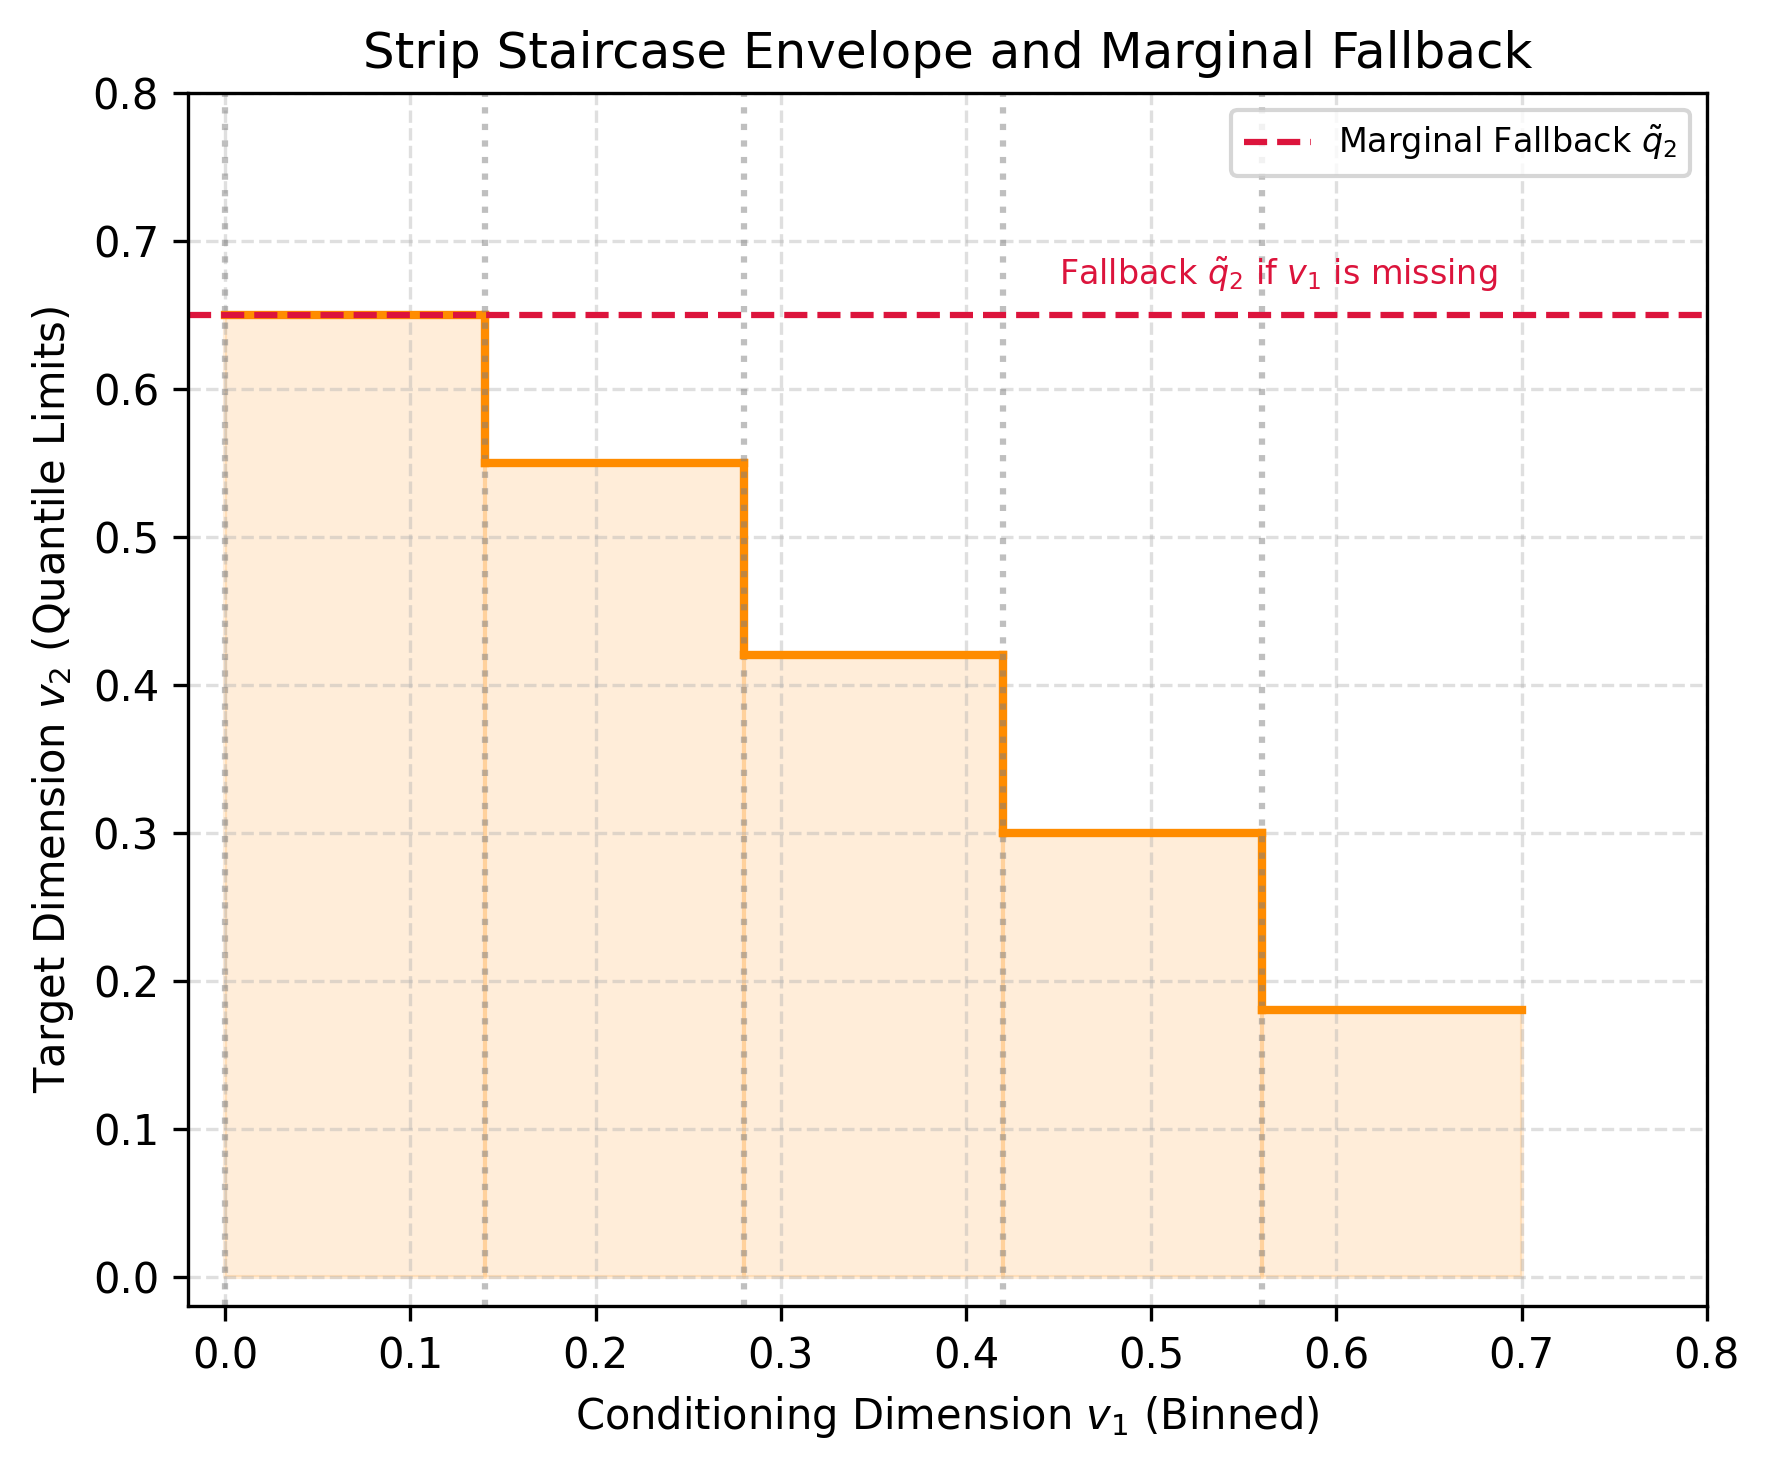

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
bins = np.linspace(0, 0.7, 6)
limits_v2 = [0.65, 0.55, 0.42, 0.30, 0.18]

# Draw bin columns and staircase boundary
for i in range(len(bins)-1):
    lo, hi = bins[i], bins[i+1]
    lim = limits_v2[i]
    ax.axvline(lo, color='gray', linestyle=':', alpha=0.5)
    ax.fill_between([lo, hi], [0, 0], [lim, lim], color='darkorange', alpha=0.15)
    ax.plot([lo, hi], [lim, lim], color='darkorange', lw=2)
    if i < len(limits_v2) - 1:
        ax.plot([hi, hi], [lim, limits_v2[i+1]], color='darkorange', lw=2)

ax.axhline(0.65, color='crimson', linestyle='--', label=r'Marginal Fallback $\tilde{q}_2$')
ax.text(0.45, 0.67, r'Fallback $\tilde{q}_2$ if $v_1$ is missing', color='crimson', fontsize=8)

ax.set_xlim(-0.02, 0.8)
ax.set_ylim(-0.02, 0.8)
ax.set_xlabel(r'Conditioning Dimension $v_1$ (Binned)')
ax.set_ylabel(r'Target Dimension $v_2$ (Quantile Limits)')
ax.set_title('Strip Staircase Envelope and Marginal Fallback')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
# plt.savefig('strip_envelope_concept.pdf')
# plt.close()


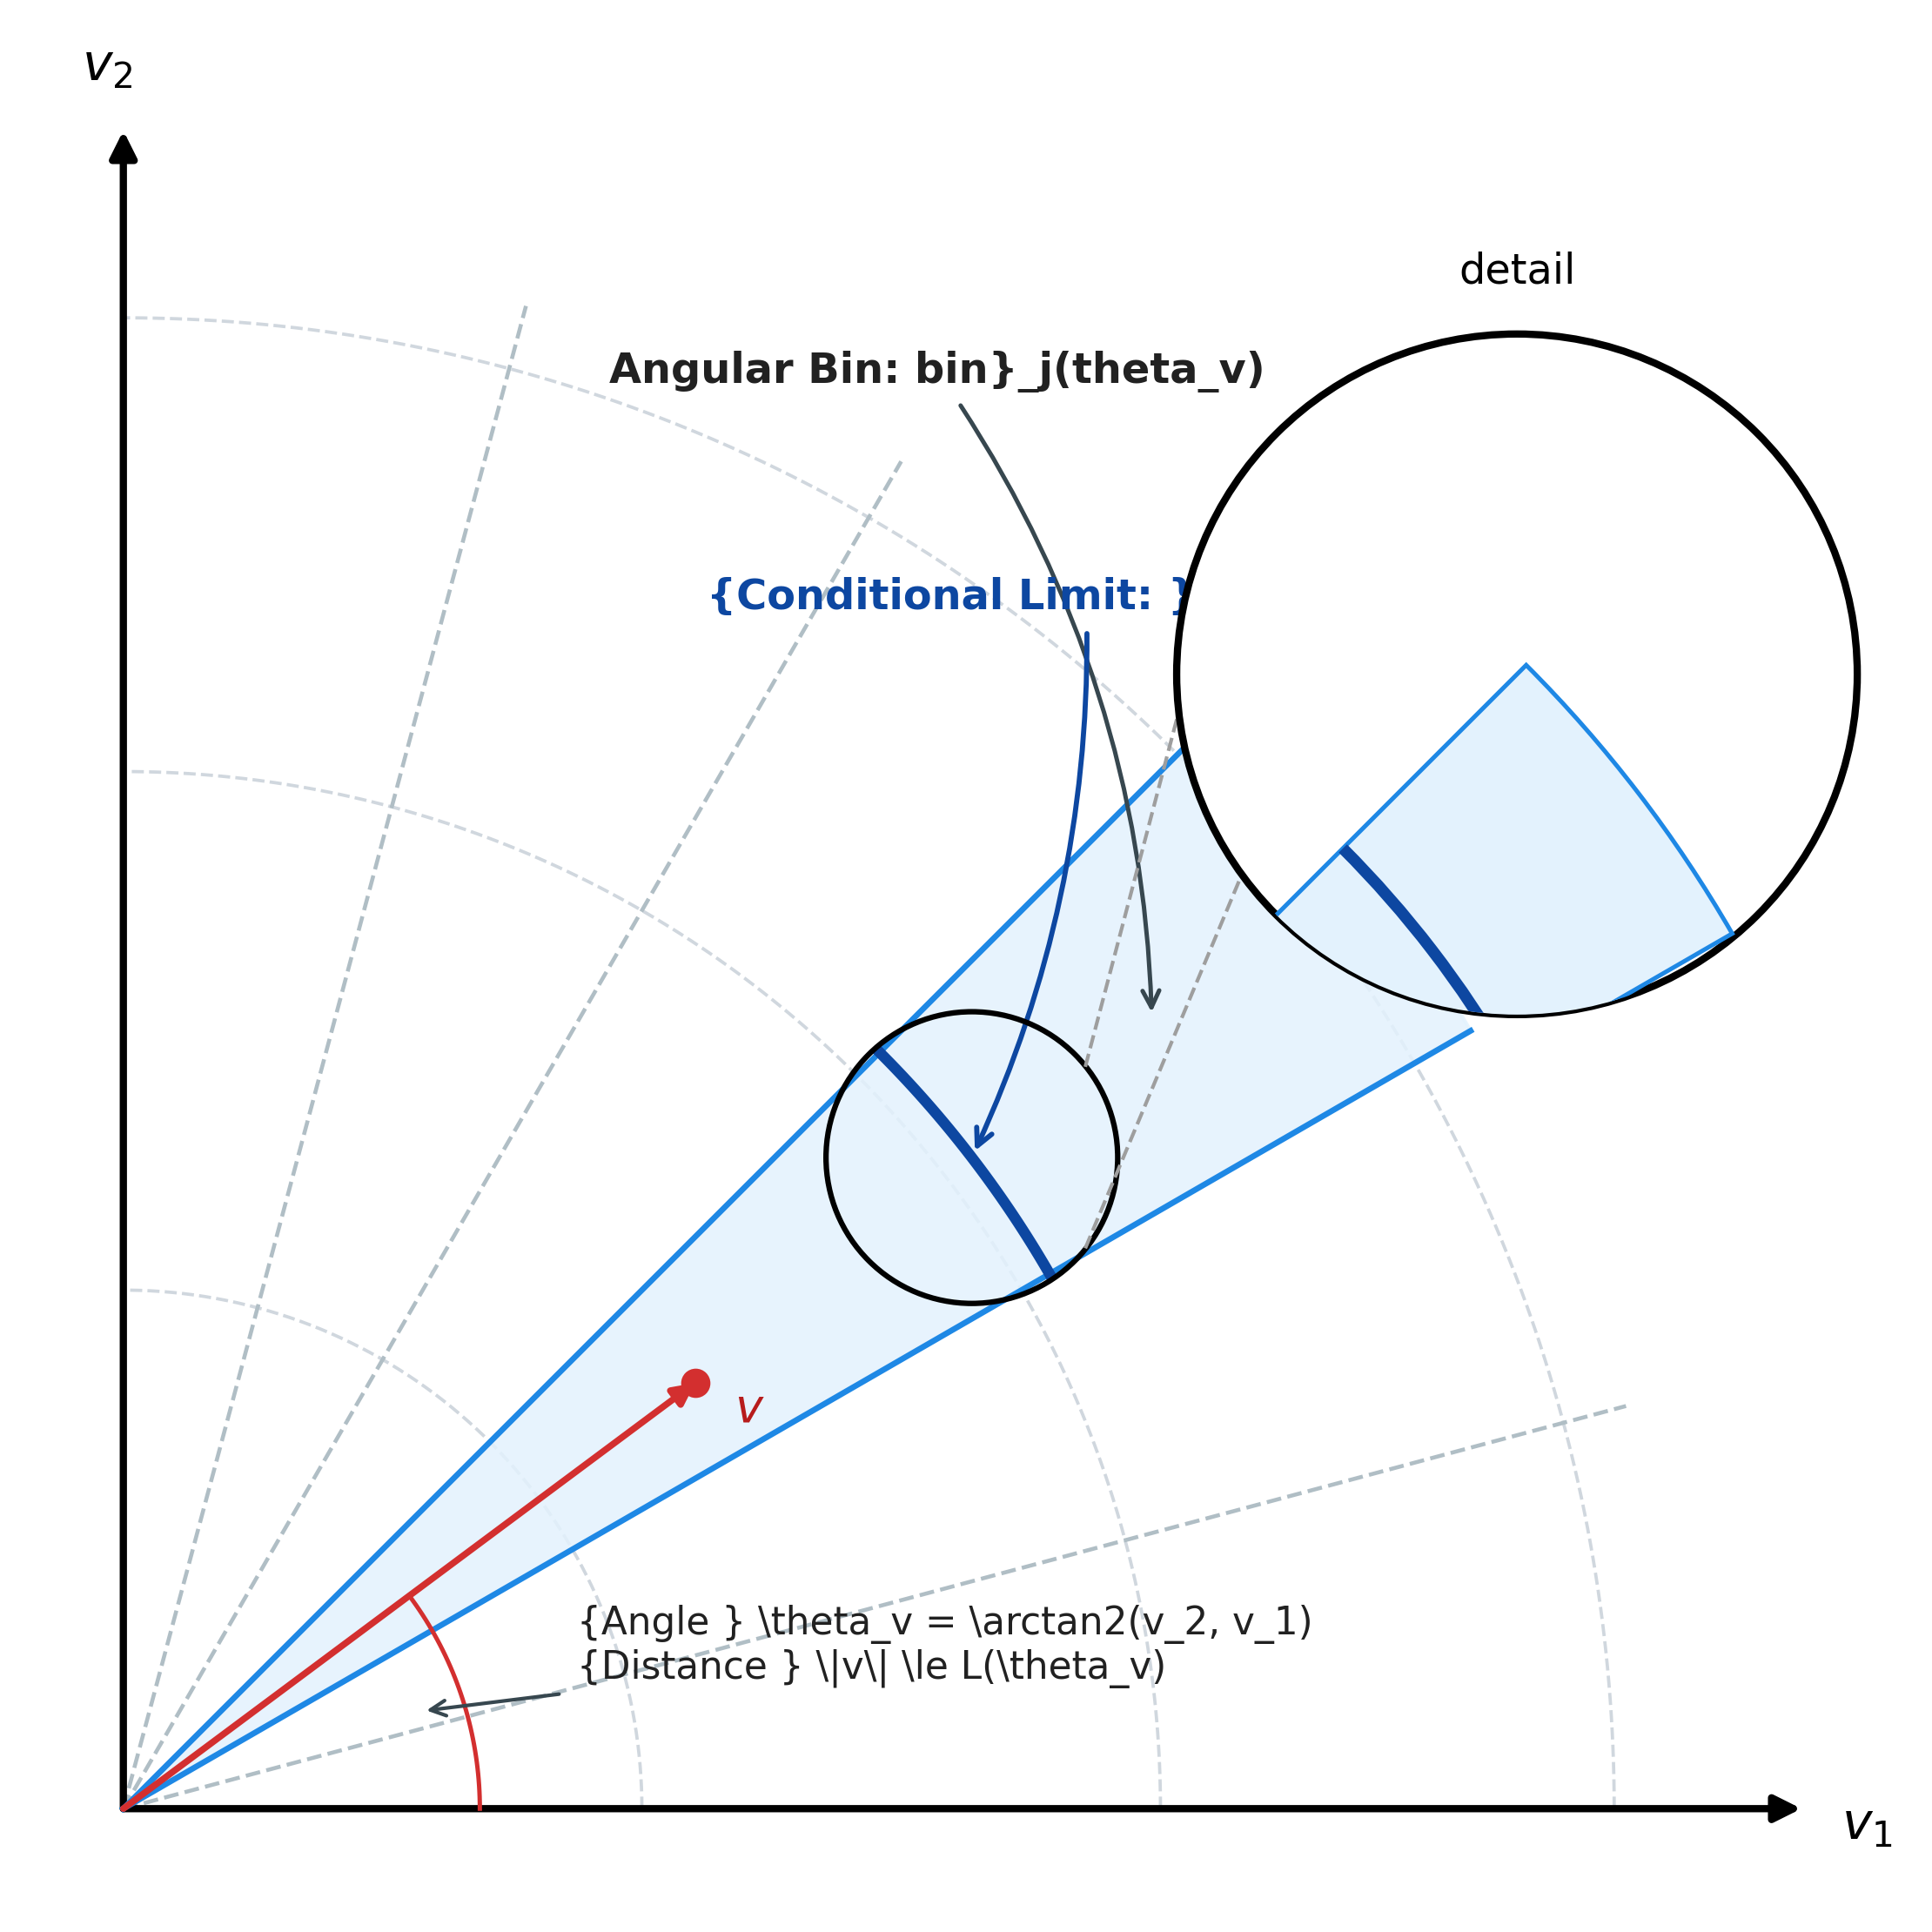

In [9]:
import io
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

# Create clean, high-resolution vector-style figure
fig, ax = plt.subplots(figsize=(8, 7.5), dpi=300)

# Axes setup
ax.set_xlim(-0.3, 5.5)
ax.set_ylim(-0.3, 5.5)
ax.set_aspect("equal")

# Coordinate Axes Arrows
ax.annotate(
    "",
    xy=(5.2, 0),
    xytext=(0, 0),
    arrowprops=dict(
        arrowstyle="-|>", color="black", lw=2, mutation_scale=15, shrinkA=0
    ),
)
ax.annotate(
    "",
    xy=(0, 5.2),
    xytext=(0, 0),
    arrowprops=dict(
        arrowstyle="-|>", color="black", lw=2, mutation_scale=15, shrinkA=0
    ),
)

ax.text(
    5.3,
    -0.05,
    r"$v_1$",
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="center",
)
ax.text(
    -0.05,
    5.3,
    r"$v_2$",
    fontsize=14,
    fontweight="bold",
    ha="center",
    va="bottom",
)

# Angular Bins (Dotted rays and guide arcs)
n_bins = 6
theta_edges = np.linspace(0, np.pi / 2, n_bins + 1)
r_max = 4.8

# Concentric guide arcs
for r in [1.6, 3.2, 4.6]:
    th_dense = np.linspace(0, np.pi / 2, 150)
    ax.plot(
        r * np.cos(th_dense),
        r * np.sin(th_dense),
        color="#D0D7DE",
        linestyle="--",
        linewidth=0.9,
        zorder=1,
    )

# Dotted sector rays
for edge in theta_edges:
    ax.plot(
        [0, r_max * np.cos(edge)],
        [0, r_max * np.sin(edge)],
        color="#B0BEC5",
        linestyle="--",
        linewidth=1.1,
        zorder=1,
    )

# Stepped boundary limits for each sector
r_limits = [4.4, 3.9, 3.3, 2.7, 2.2, 1.7]

# Highlighted active sector (Bin index 2: 30 deg to 45 deg)
active_idx = 2
th_start, th_end = theta_edges[active_idx], theta_edges[active_idx + 1]
r_active = r_limits[active_idx]

# Fill active sector
th_fill = np.linspace(th_start, th_end, 50)
x_fill = np.concatenate([[0], r_max * np.cos(th_fill), [0]])
y_fill = np.concatenate([[0], r_max * np.sin(th_fill), [0]])
ax.fill(x_fill, y_fill, color="#E3F2FD", alpha=0.85, zorder=2)

# Emphasize active ray sector boundaries
ax.plot(
    [0, r_max * np.cos(th_start)],
    [0, r_max * np.sin(th_start)],
    color="#1E88E5",
    linewidth=1.6,
    zorder=3,
)
ax.plot(
    [0, r_max * np.cos(th_end)],
    [0, r_max * np.sin(th_end)],
    color="#1E88E5",
    linewidth=1.6,
    zorder=3,
)

# Draw the conditional limit arc for the active bin
ax.plot(
    r_active * np.cos(th_fill),
    r_active * np.sin(th_fill),
    color="#0D47A1",
    linewidth=3.0,
    zorder=4,
)

# Test vector v
v_th = 0.64
v_r = 2.2
v_x, v_y = v_r * np.cos(v_th), v_r * np.sin(v_th)

# Vector arrow and point
ax.annotate(
    "",
    xy=(v_x, v_y),
    xytext=(0, 0),
    arrowprops=dict(
        arrowstyle="-|>",
        color="#D32F2F",
        lw=1.8,
        mutation_scale=12,
        shrinkA=0,
        shrinkB=0,
    ),
    zorder=5,
)
ax.scatter([v_x], [v_y], color="#D32F2F", s=50, zorder=6)
ax.text(
    v_x + 0.12,
    v_y - 0.12,
    r"$v$",
    fontsize=13,
    fontweight="bold",
    color="#B71C1C",
    zorder=6,
)

# Angle theta_v arc
arc_th = np.linspace(0, v_th, 40)
ax.plot(
    1.1 * np.cos(arc_th),
    1.1 * np.sin(arc_th),
    color="#D32F2F",
    linewidth=1.2,
    zorder=4,
)

# --- Labels and Callouts ---
# Angle and distance description
ax.annotate(
    r"{Angle } \theta_v = \arctan2(v_2, v_1)"
    + "\n"
    + r"{Distance } \|v\| \le L(\theta_v)",
    xy=(0.95 * np.cos(v_th / 2), 0.95 * np.sin(v_th / 2)),
    xytext=(1.4, 0.4),
    fontsize=10.5,
    color="#212121",
    arrowprops=dict(
        arrowstyle="->", color="#37474F", lw=1.0, shrinkA=3, shrinkB=3
    ),
    zorder=6,
)

# Angular Bin callout
mid_th = (th_start + th_end) / 2
ax.annotate(
    r"Angular Bin: bin}_j(theta_v)",
    xy=(4.0 * np.cos(mid_th), 4.0 * np.sin(mid_th)),
    xytext=(1.5, 4.4),
    fontsize=11.5,
    fontweight="semibold",
    color="#212121",
    arrowprops=dict(
        arrowstyle="->",
        color="#37474F",
        lw=1.2,
        connectionstyle="arc3,rad=-0.15",
    ),
    zorder=6,
)

# Conditional limit callout
ax.annotate(
    r"{Conditional Limit: } L(\theta_v)",
    xy=(r_active * np.cos(mid_th), r_active * np.sin(mid_th)),
    xytext=(1.8, 3.7),
    fontsize=11.5,
    fontweight="semibold",
    color="#0D47A1",
    arrowprops=dict(
        arrowstyle="->",
        color="#0D47A1",
        lw=1.4,
        connectionstyle="arc3,rad=-0.12",
    ),
    zorder=6,
)

# Zoom Detail Circle around the limit
zoom_center_x = r_active * np.cos(mid_th)
zoom_center_y = r_active * np.sin(mid_th)
zoom_radius = 0.45
circle_patch = patches.Circle(
    (zoom_center_x, zoom_center_y),
    zoom_radius,
    edgecolor="black",
    facecolor="none",
    linewidth=1.5,
    zorder=7,
)
ax.add_patch(circle_patch)

# Zoomed Inset Circle
inset_center_x, inset_center_y = 4.3, 3.5
inset_radius = 1.05
inset_bg = patches.Circle(
    (inset_center_x, inset_center_y),
    inset_radius,
    edgecolor="black",
    facecolor="white",
    linewidth=2.0,
    zorder=8,
)
ax.add_patch(inset_bg)

# Inset connector lines
ax.plot(
    [zoom_center_x + 0.35, inset_center_x - 0.85],
    [zoom_center_y + 0.28, inset_center_y + 0.62],
    color="#9E9E9E",
    linestyle="--",
    linewidth=1.0,
    zorder=7,
)
ax.plot(
    [zoom_center_x + 0.35, inset_center_x - 0.85],
    [zoom_center_y - 0.28, inset_center_y - 0.62],
    color="#9E9E9E",
    linestyle="--",
    linewidth=1.0,
    zorder=7,
)

# Inset contents
inset_th = np.linspace(th_start, th_end, 50)
inset_wedge = patches.Wedge(
    (inset_center_x - 2.8, inset_center_y - 2.8),
    4.0,
    np.degrees(th_start),
    np.degrees(th_end),
    facecolor="#E3F2FD",
    edgecolor="#1E88E5",
    linewidth=1.2,
    zorder=9,
)
inset_wedge.set_clip_path(inset_bg)
ax.add_patch(inset_wedge)

# Inset arc boundary
inset_arc = patches.Arc(
    (inset_center_x - 2.8, inset_center_y - 2.8),
    6.4,
    6.4,
    angle=0,
    theta1=np.degrees(th_start),
    theta2=np.degrees(th_end),
    edgecolor="#0D47A1",
    linewidth=3.2,
    zorder=10,
)
inset_arc.set_clip_path(inset_bg)
ax.add_patch(inset_arc)

# Detail label
ax.text(
    inset_center_x,
    inset_center_y + 1.18,
    "detail",
    fontsize=11.5,
    ha="center",
    va="bottom",
    zorder=11,
)

# Style clean up
ax.axis("off")
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'figures/data_generation_pipeline.png'

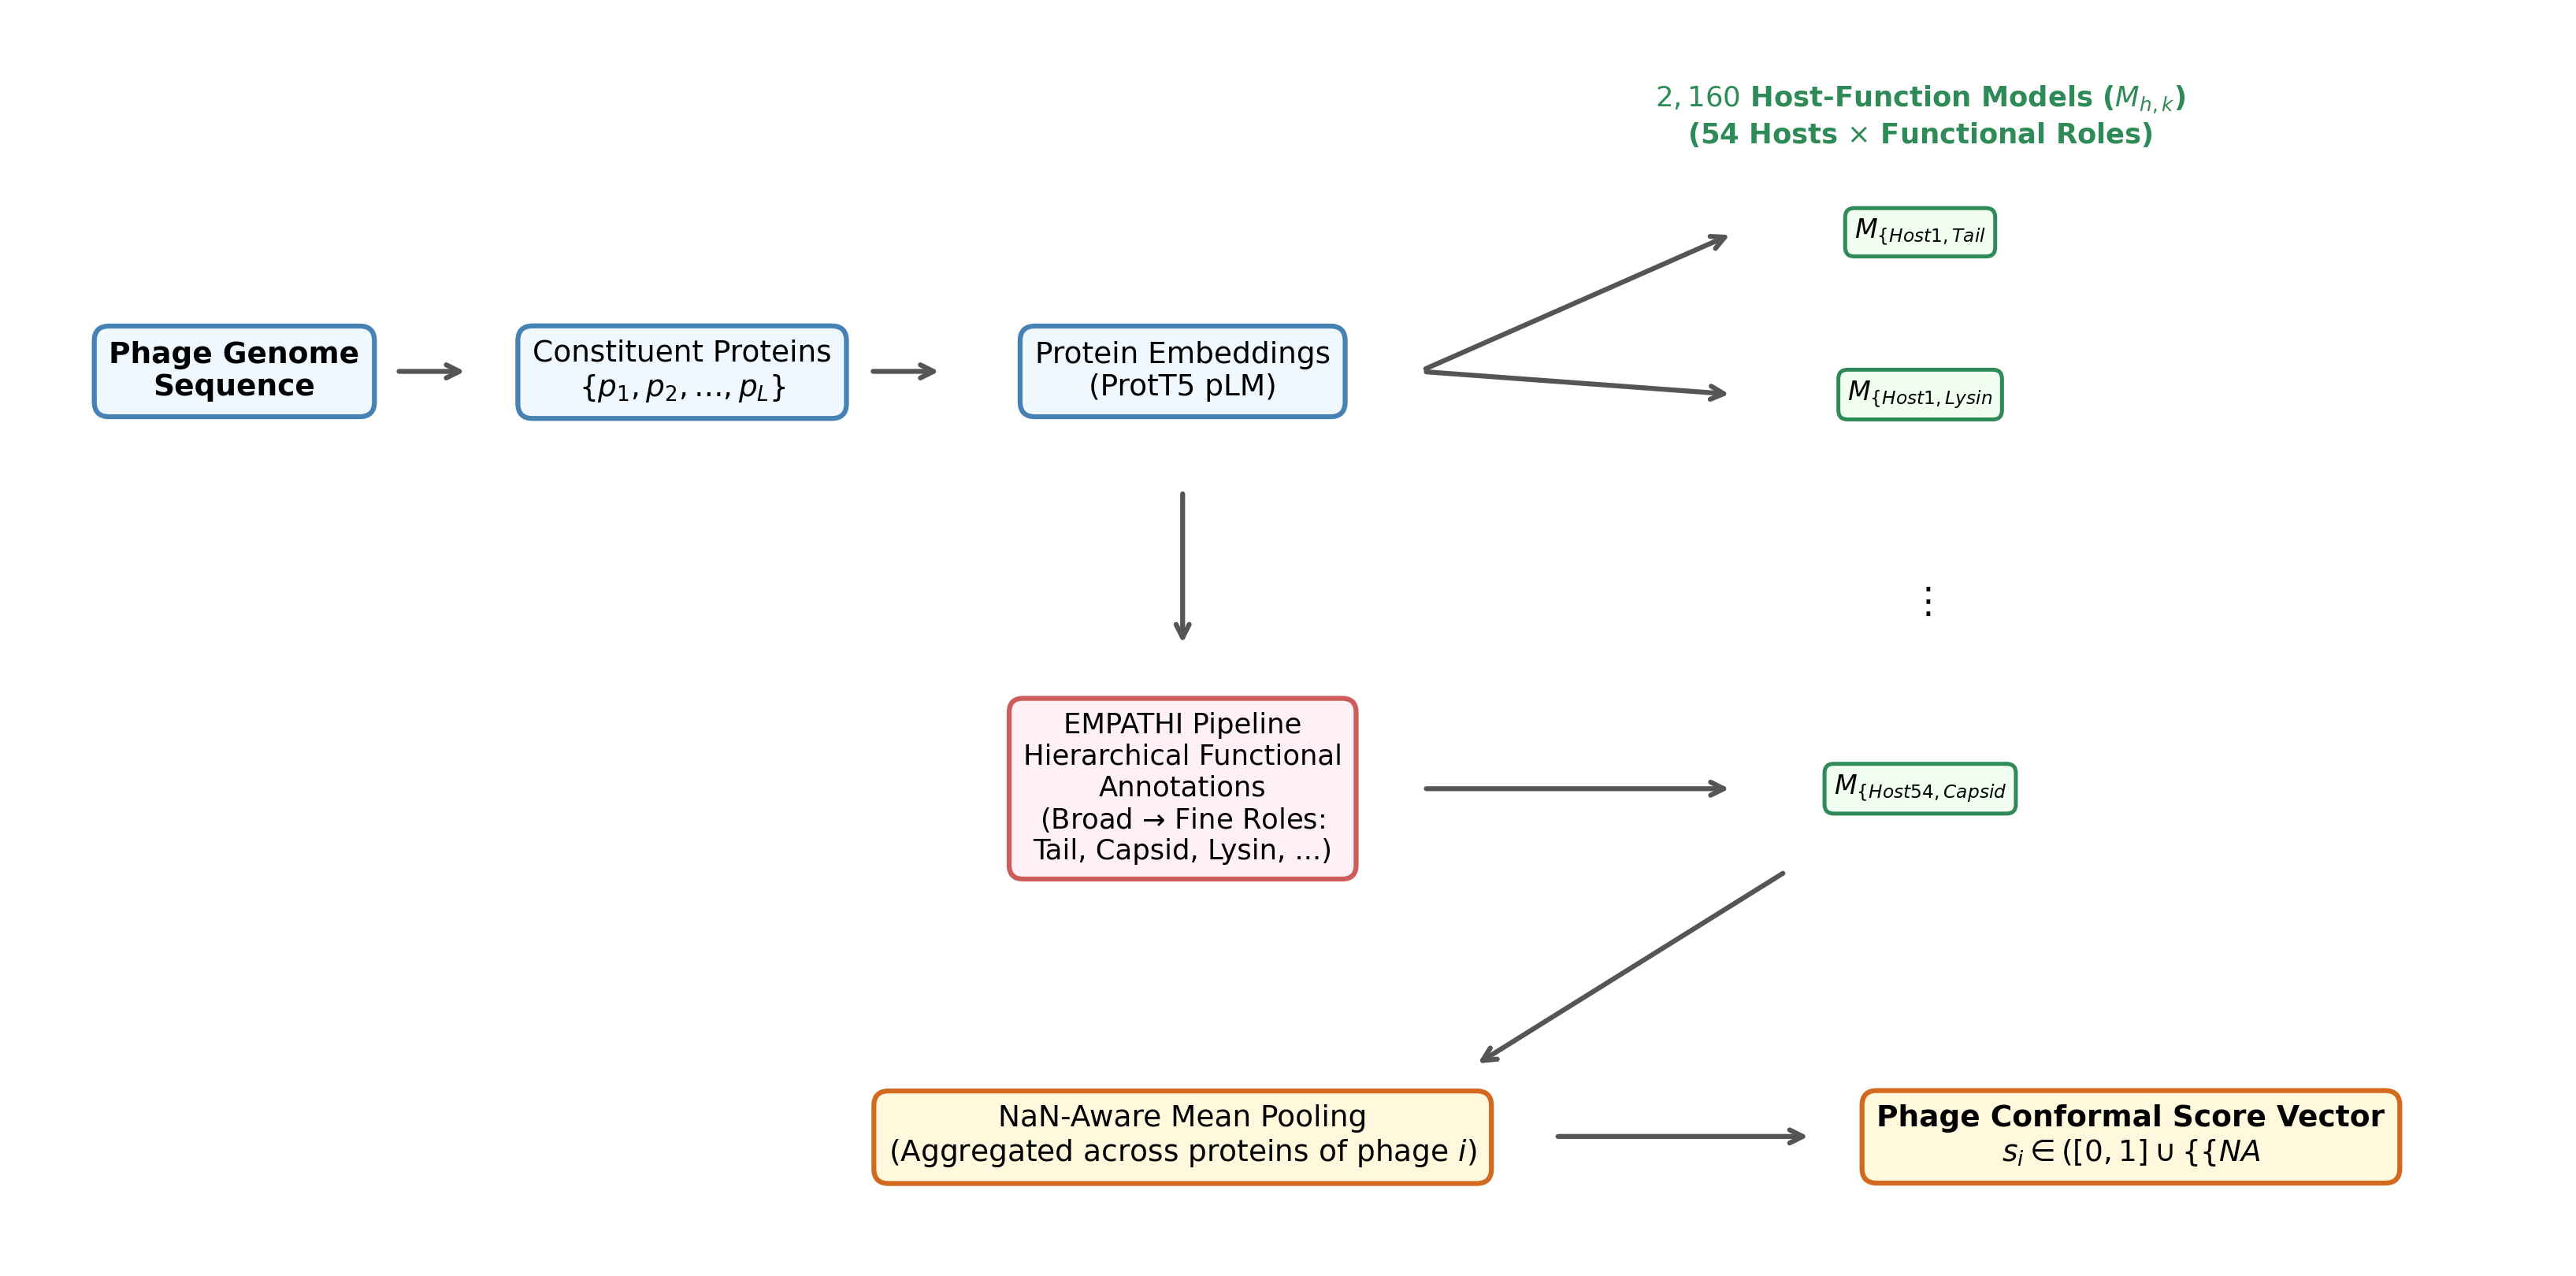

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=300)
ax.axis('off')

# Box styles
box_style = dict(boxstyle="round,pad=0.5", fc="#F0F8FF", ec="#4682B4", lw=1.5)
empathi_style = dict(boxstyle="round,pad=0.5", fc="#FFF0F5", ec="#CD5C5C", lw=1.5)
model_box = dict(boxstyle="round,pad=0.35", fc="#F0FFF0", ec="#2E8B57", lw=1.2)
agg_box = dict(boxstyle="round,pad=0.5", fc="#FFF8DC", ec="#D2691E", lw=1.5)
arrow_style = dict(arrowstyle="->", lw=1.5, color="#555555")

# 1. Genome
ax.text(0.08, 0.78, "Phage Genome\nSequence", ha="center", va="center", bbox=box_style, fontsize=9, fontweight="bold")

# 2. Proteins
ax.text(0.25, 0.78, "Constituent Proteins\n$\{p_1, p_2, \dots, p_L\}$", ha="center", va="center", bbox=box_style, fontsize=9)

# 3. pLM Embeddings
ax.text(0.44, 0.78, "Protein Embeddings\n(ProtT5 pLM)", ha="center", va="center", bbox=box_style, fontsize=9)

# 4. EMPATHI Hierarchical Functions
ax.text(0.44, 0.42, "EMPATHI Pipeline\nHierarchical Functional\nAnnotations\n(Broad $\\to$ Fine Roles:\nTail, Capsid, Lysin, ...)", ha="center", va="center", bbox=empathi_style, fontsize=8.5)

# 5. 2,160 Host-Function Models
ax.text(0.72, 0.90, "$M_{\\{Host 1, Tail}}$", ha="center", va="center", bbox=model_box, fontsize=8)
ax.text(0.72, 0.76, "$M_{\\{Host 1, Lysin}}$", ha="center", va="center", bbox=model_box, fontsize=8)
ax.text(0.72, 0.58, "$\\vdots$", ha="center", va="center", fontsize=11)
ax.text(0.72, 0.42, "$M_{\\{Host 54, Capsid}}$", ha="center", va="center", bbox=model_box, fontsize=8)
ax.text(0.72, 1.00, "$2,160$ Host-Function Models ($M_{h,k}$)\n(54 Hosts $\\times$ Functional Roles)", ha="center", va="center", fontsize=8.5, fontweight="bold", color="#2E8B57")

# 6. Pooling and Final Score Vector
ax.text(0.44, 0.12, "NaN-Aware Mean Pooling\n(Aggregated across proteins of phage $i$)", ha="center", va="center", bbox=agg_box, fontsize=9)
ax.text(0.80, 0.12, "Phage Conformal Score Vector\n$s_i \\in ([0,1] \\cup \\{\\{NA}\\})^{2036}$", ha="center", va="center", bbox=agg_box, fontsize=9, fontweight="bold")

# Arrows
ax.annotate("", xy=(0.17, 0.78), xytext=(0.14, 0.78), arrowprops=arrow_style)
ax.annotate("", xy=(0.35, 0.78), xytext=(0.32, 0.78), arrowprops=arrow_style)

# Embedding to EMPATHI and Models
ax.annotate("", xy=(0.44, 0.54), xytext=(0.44, 0.68), arrowprops=arrow_style)
ax.annotate("", xy=(0.65, 0.90), xytext=(0.53, 0.78), arrowprops=arrow_style)
ax.annotate("", xy=(0.65, 0.76), xytext=(0.53, 0.78), arrowprops=arrow_style)
ax.annotate("", xy=(0.65, 0.42), xytext=(0.53, 0.42), arrowprops=arrow_style)

# Models to Pooling
ax.annotate("", xy=(0.55, 0.18), xytext=(0.67, 0.35), arrowprops=arrow_style)
ax.annotate("", xy=(0.68, 0.12), xytext=(0.58, 0.12), arrowprops=arrow_style)

plt.xlim(0, 0.96)
plt.ylim(0.02, 1.08)
plt.tight_layout()
plt.savefig("figures/data_generation_pipeline.png", dpi=300)
plt.close()